In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import optuna
from src import pre_process_data_multidim, prepare_data, prepare_data_multidim, read_yfinance_crypto_data, full_evaluation_flow, optimize_hyperparameters, split_data_set, model_builder

/var/home/joshua-junker/.cache/pypoetry/virtualenvs/cryptobot-enviroment-eGOy9P3u-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-02 15:39:46.203953: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-02 15:39:46.285788: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-02 15:39:46.375249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738521586.477624  728918 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [3]:
# Fetch Ripple price data
df = read_yfinance_crypto_data("EURUSD=x", "max", "1h")
scaler = MinMaxScaler()

[
    [train_date_series, train_data, normalized_data],
    [test_date_series, testData, normalized_test_data]
] = pre_process_data_multidim(
    [
        df["Close"],
        df["Volume"]
    ], scaler)

print(f"Train Data: {train_data.shape}\nTest Data: {testData.shape}")

test_target = testData
print(f"Train Target: {train_data.shape}\nTest Data: {test_target.shape}")

[array([[1.08143175],
       [1.08073056],
       [1.07968044],
       ...,
       [1.03766727],
       [1.03626943],
       [1.03626943]]), array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])]
(12317, 2)
(12317, 2)
Cutoff:  3695
Cutoff:  3695
Cutoff:  3695
Train Data: (8622, 2)
Test Data: (3695, 2)
Train Target: (8622, 2)
Test Data: (3695, 2)


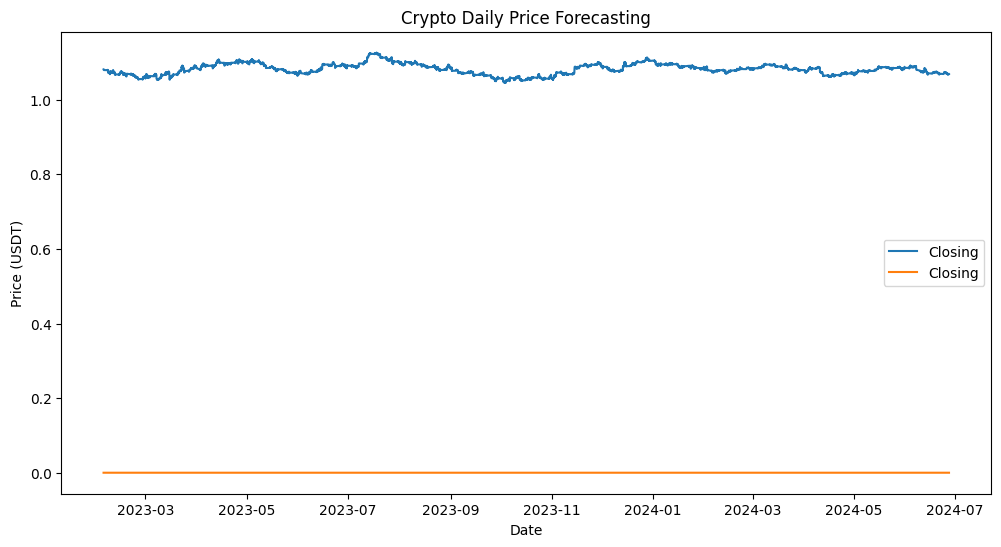

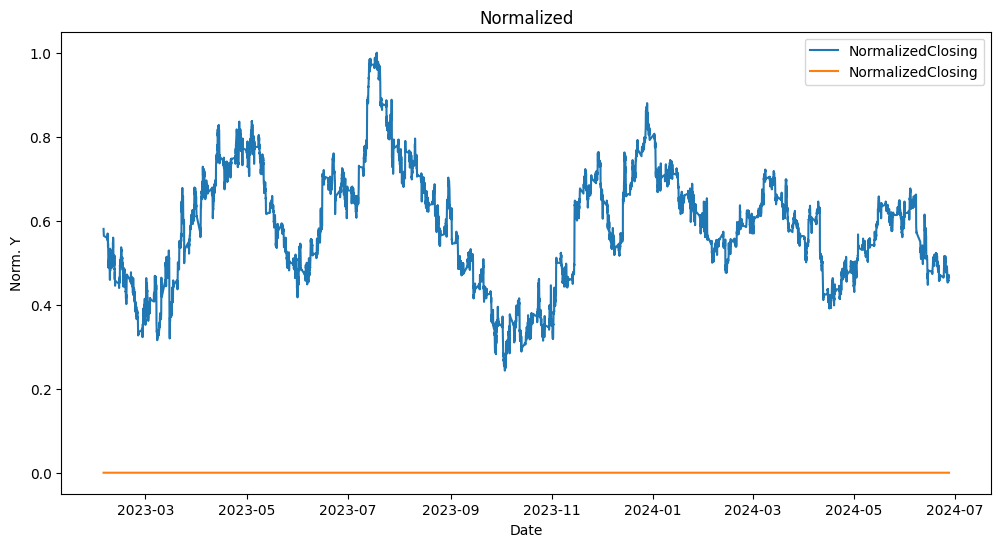

In [4]:
# Plot train data
plt.figure(figsize=(12, 6))
plt.plot(train_date_series, train_data[:], label='Closing')
plt.title('Crypto Daily Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(train_date_series, normalized_data, label='NormalizedClosing')
plt.title('Normalized')
plt.xlabel('Date')
plt.ylabel('Norm. Y')
plt.legend()
plt.show()

In [5]:
# Prepare data for each EWT component
seq_len = 90
print(normalized_data.shape)
X, y, train_data, train_date_series = prepare_data_multidim(
    normalized_data,
    train_data,
    train_date_series,
    seq_len
)

print(y.shape, X.shape, train_date_series.shape, train_data.shape)

(8622, 2)
(8622, 2) (8622, 2)
(8532, 1) (8532, 90, 2) (8532,) (8532, 2)


In [6]:
# The training data is separated in a train set to train each opt iteration and a validation one
# to validate each iteration.

x_train, x_val = split_data_set(X, 0.3)
y_train, y_val = split_data_set(y, 0.3)

print(x_train.shape, x_val.shape)

Cutoff:  2559
Cutoff:  2559
(5973, 90, 2) (2559, 90, 2)


In [ ]:
model = model_builder(
    246,
    0.22247614754696465,
    55,
    0.0007413033489541297,
    x_train[0].shape
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=16,
    epochs=136,
    verbose=1
)

Epoch 1/136


2025-02-02 15:40:38.515751: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


374/374 ━━━━━━━━━━━━━━━━━━━━ 138s 363ms/step - loss: 0.0517 - val_loss: 1.3328e-04
Epoch 2/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 131s 349ms/step - loss: 9.2931e-05 - val_loss: 1.1143e-05
Epoch 3/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 132s 352ms/step - loss: 6.2174e-05 - val_loss: 1.0174e-04
Epoch 4/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 145s 388ms/step - loss: 4.0171e-05 - val_loss: 8.4726e-06
Epoch 5/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 114s 304ms/step - loss: 3.6623e-05 - val_loss: 1.5727e-04
Epoch 6/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 132s 353ms/step - loss: 5.6497e-05 - val_loss: 6.0907e-05
Epoch 7/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 143s 382ms/step - loss: 4.3935e-05 - val_loss: 2.0244e-06
Epoch 8/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 118s 314ms/step - loss: 4.3744e-05 - val_loss: 8.6395e-06
Epoch 9/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 113s 302ms/step - loss: 3.3766e-05 - val_loss: 4.1290e-06
Epoch 10/136
374/374 ━━━━━━━━━━━━━━━━━━━━ 2168s 6s/step - loss: 3.6514e-05 - val_loss: 2.7605e-05
Epoch 11/136
374/374 ━━━━━━

In [ ]:
full_evaluation_flow(
    model,
    prepare_data_multidim,
    normalized_test_data,
    testData,
    test_date_series,
    seq_len,
    "eurusd-multi-feature-optimized-hyperp"
)

In [ ]:
!mkdir -p saved_models
model.save("saved_models/eurusd-multi-feat-opt-hyperp-p90-2L.keras")